# Quantum Complexity Validation

This notebook validates our implementation of quantum complexity measures against known analytic values from the literature.

## Key References
- Gu et al. (2012) "Quantum mechanics can reduce the complexity of classical models"
- Thompson et al. (2018) "Causal Asymmetry in a Quantum World"

## Key Hierarchy
The fundamental inequality is:
$$E \leq C_q \leq C_\mu$$

where:
- $E$ = excess entropy (mutual information between past and future)
- $C_q$ = quantum statistical complexity  
- $C_\mu$ = classical statistical complexity

In [15]:
# Setup: ensure we use the local development version of emic
import sys
from pathlib import Path

# Clear any cached emic modules
for mod in list(sys.modules.keys()):
    if "emic" in mod:
        del sys.modules[mod]

# Add the src directory to the path (quantum-research worktree)
src_path = "/workspace/worktrees/quantum-research/src"
# Put it first to ensure it takes precedence
sys.path = [src_path] + [p for p in sys.path if p != src_path]
print(f"sys.path[0] = {sys.path[0]}")

sys.path[0] = /workspace/worktrees/quantum-research/src


In [16]:
import math
import numpy as np
import pandas as pd

from emic.sources.synthetic.perturbed_coin import PerturbedCoinSource
from emic.sources.synthetic.golden_mean import GoldenMeanSource
from emic.sources.synthetic.biased_coin import BiasedCoinSource
from emic.analysis import (
    statistical_complexity,
    entropy_rate,
    excess_entropy,
    crypticity,
    quantum_complexity,
    quantum_advantage,
    quantum_density_matrix,
    quantum_signal_states,
    decoherence_trajectory,
)

## Part 1: Perturbed Coin - The Canonical Example

The perturbed coin is the simplest process with quantum advantage. It's a coin with persistent bias:
- State S0: last observation was 0
- State S1: last observation was 1
- With probability p, the coin "flips" to the other state
- With probability 1-p, it stays

**Known exact formulas:**
- $C_\mu = 1$ bit (always, two equally likely states)
- $h_\mu = H_s(p)$ (binary entropy of flip probability)
- $E = 1 - H_s(p)$
- $\chi = H_s(p)$ (crypticity = classical waste)

**Quantum signal states:**
$$|s_0\rangle = \sqrt{1-p}|0,0\rangle + \sqrt{p}|1,1\rangle$$
$$|s_1\rangle = \sqrt{p}|0,0\rangle + \sqrt{1-p}|1,1\rangle$$

**Density matrix eigenvalues:** $\lambda_\pm = 0.5 \pm \sqrt{p(1-p)}$

**Quantum complexity:** $C_q = S(\rho) = -\lambda_+ \log_2 \lambda_+ - \lambda_- \log_2 \lambda_-$

In [17]:
# Helper: binary entropy
def H_s(p: float) -> float:
    """Binary (Shannon) entropy in bits."""
    if p <= 0 or p >= 1:
        return 0.0
    return -p * math.log2(p) - (1 - p) * math.log2(1 - p)


# Helper: expected C_q for perturbed coin (analytic formula)
def perturbed_coin_C_q(p: float) -> float:
    """Analytic C_q for perturbed coin."""
    sqrt_term = math.sqrt(p * (1 - p))
    lambda_plus = 0.5 + sqrt_term
    lambda_minus = 0.5 - sqrt_term

    s = 0.0
    for lam in [lambda_plus, lambda_minus]:
        if lam > 1e-12:
            s -= lam * math.log2(lam)
    return s


print("Helper functions defined: H_s(p), perturbed_coin_C_q(p)")

Helper functions defined: H_s(p), perturbed_coin_C_q(p)


In [19]:
# Validate classical measures for perturbed coin
p_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]

results = []
for p in p_values:
    source = PerturbedCoinSource(p=p)
    machine = source.true_machine

    c_mu = statistical_complexity(machine)
    h_mu = entropy_rate(machine)
    e = excess_entropy(machine)
    chi = crypticity(machine)

    # Expected values
    expected_h = H_s(p)
    expected_e = 1.0 - H_s(p)
    expected_chi = H_s(p)

    results.append(
        {
            "p": p,
            "C_μ": c_mu,
            "h_μ": h_mu,
            "h_μ (expected)": expected_h,
            "E": e,
            "E (expected)": expected_e,
            "χ": chi,
            "χ (expected)": expected_chi,
        }
    )

df = pd.DataFrame(results)
print("Classical measures for Perturbed Coin")
print("=" * 80)
df

Classical measures for Perturbed Coin


,p,C_μ,h_μ,h_μ (expected),E,E (expected),χ,χ (expected)
0,0.05,1.0,0.286397,0.286397,0.713603,0.713603,0.286397,0.286397
1,0.10,1.0,0.468996,0.468996,0.531004,0.531004,0.468996,0.468996
2,0.15,1.0,0.609840,0.609840,0.390160,0.390160,0.609840,0.609840
3,0.20,1.0,0.721928,0.721928,0.278072,0.278072,0.721928,0.721928
4,0.25,1.0,0.811278,0.811278,0.188722,0.188722,0.811278,0.811278
5,0.30,1.0,0.881291,0.881291,0.118709,0.118709,0.881291,0.881291
6,0.35,1.0,0.934068,0.934068,0.065932,0.065932,0.934068,0.934068
7,0.40,1.0,0.970951,0.970951,0.029049,0.029049,0.970951,0.970951
8,0.45,1.0,0.992774,0.992774,0.007226,0.007226,0.992774,0.992774


### 1.2 Quantum Complexity Validation

Now compute quantum complexity and validate against the analytic formula.

In [20]:
# Compute quantum complexity for perturbed coin
quantum_results = []
for p in p_values:
    source = PerturbedCoinSource(p=p)
    machine = source.true_machine

    c_mu = statistical_complexity(machine)
    e = excess_entropy(machine)
    c_q = quantum_complexity(machine)
    c_q_expected = perturbed_coin_C_q(p)
    delta_q = quantum_advantage(machine)

    # Check hierarchy
    hierarchy_ok = (e <= c_q + 1e-6) and (c_q <= c_mu + 1e-6)

    quantum_results.append(
        {
            "p": p,
            "C_μ": c_mu,
            "E": e,
            "C_q": c_q,
            "C_q (expected)": c_q_expected,
            "Δ_q": delta_q,
            "E ≤ C_q ≤ C_μ": "✓" if hierarchy_ok else "✗",
        }
    )

df_q = pd.DataFrame(quantum_results)
print("Quantum complexity for Perturbed Coin")
print("=" * 80)
df_q

Quantum complexity for Perturbed Coin


,p,C_μ,E,C_q,C_q (expected),Δ_q,E ≤ C_q ≤ C_μ
0,0.05,1.0,0.713603,0.858236,0.858236,0.141764,✓
1,0.10,1.0,0.531004,0.721928,0.721928,0.278072,✓
2,0.15,1.0,0.390160,0.591857,0.591857,0.408143,✓
3,0.20,1.0,0.278072,0.468996,0.468996,0.531004,✓
4,0.25,1.0,0.188722,0.354579,0.354579,0.645421,✓
5,0.30,1.0,0.118709,0.250225,0.250225,0.749775,✓
6,0.35,1.0,0.065932,0.158133,0.158133,0.841867,✓
7,0.40,1.0,0.029049,0.081469,0.081469,0.918531,✓
8,0.45,1.0,0.007226,0.025266,0.025266,0.974734,✓


### 1.3 Inspect the Quantum Construction

Let's look at the actual signal states and density matrix for p=0.3 to understand the construction.

In [21]:
# Inspect quantum construction for p=0.3
p = 0.3
source = PerturbedCoinSource(p=p)
machine = source.true_machine

# Get signal states
states, state_ids, symbols = quantum_signal_states(machine)
print(f"Perturbed Coin with p={p}")
print("=" * 60)
print(
    f"\nHilbert space: {len(symbols)} symbols × {len(state_ids)} states = {len(states[0])} dimensions"
)
print(f"Basis: |symbol, target_state⟩ with ordering: ", end="")
for x in symbols:
    for sid in state_ids:
        print(f"|{x},{sid}⟩ ", end="")
print("\n")

print("Signal states:")
for psi, sid in zip(states, state_ids):
    # Show only non-zero components
    nonzero = [(i, psi[i]) for i in range(len(psi)) if abs(psi[i]) > 1e-10]
    print(f"  |s_{sid}⟩ = ", end="")
    terms = []
    for i, amp in nonzero:
        x_idx = i // len(state_ids)
        k_idx = i % len(state_ids)
        terms.append(f"{amp.real:.4f}|{symbols[x_idx]},{state_ids[k_idx]}⟩")
    print(" + ".join(terms))

Perturbed Coin with p=0.3

Hilbert space: 2 symbols × 2 states = 4 dimensions
Basis: |symbol, target_state⟩ with ordering: |0,S0⟩ |0,S1⟩ |1,S0⟩ |1,S1⟩ 

Signal states:
  |s_S0⟩ = 0.8367|0,S0⟩ + 0.5477|1,S1⟩
  |s_S1⟩ = 0.5477|0,S0⟩ + 0.8367|1,S1⟩


In [23]:
# Density matrix and eigenvalues
rho = quantum_density_matrix(machine)

print("Density matrix ρ (4×4, but only 2×2 subspace is non-zero):")
print(f"\nFull matrix:\n{np.round(rho.real, 4)}")

eigenvalues = np.linalg.eigvalsh(rho)
print(f"\nEigenvalues: {np.round(eigenvalues, 6)}")

# Compare with expected
sqrt_term = math.sqrt(p * (1 - p))
expected_eigs = [0.5 + sqrt_term, 0.5 - sqrt_term]
print(f"Expected (from formula): {expected_eigs}")

# Von Neumann entropy
nonzero_eigs = eigenvalues[eigenvalues > 1e-12]
entropy = -np.sum(nonzero_eigs * np.log2(nonzero_eigs))
print(f"\nC_q = S(ρ) = {entropy:.6f} bits")

Density matrix ρ (4×4, but only 2×2 subspace is non-zero):

Full matrix:
[[0.3333 0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.3333 0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.3333]]

Eigenvalues: [0.       0.       0.       0.       0.       0.       0.333333 0.333333
 0.333333]
Expected (from formula): [0.9898979485566356, 0.010102051443364402]

C_q = S(ρ) = 1.584963 bits


### 1.4 Discrepancy with Validation Plan Table

The validation plan table (extracted from Gu et al. 2012 Fig. 2) has different $C_q$ values. 
Let's investigate this discrepancy.

In [24]:
# Compare with validation plan table (claimed to be from Gu et al. 2012 Fig. 2)
validation_table = {
    0.05: {"E": 0.714, "C_q": 0.714},
    0.10: {"E": 0.531, "C_q": 0.469},
    0.15: {"E": 0.390, "C_q": 0.352},
    0.20: {"E": 0.278, "C_q": 0.286},
    0.25: {"E": 0.189, "C_q": 0.219},
    0.30: {"E": 0.119, "C_q": 0.161},
    0.35: {"E": 0.066, "C_q": 0.114},
    0.40: {"E": 0.029, "C_q": 0.080},
}

comparison = []
for p, expected in validation_table.items():
    source = PerturbedCoinSource(p=p)
    machine = source.true_machine

    e = excess_entropy(machine)
    c_q = quantum_complexity(machine)
    c_q_formula = perturbed_coin_C_q(p)

    comparison.append(
        {
            "p": p,
            "E (ours)": round(e, 4),
            "E (table)": expected["E"],
            "E match": "✓" if abs(e - expected["E"]) < 0.01 else "✗",
            "C_q (ours)": round(c_q, 4),
            "C_q (formula)": round(c_q_formula, 4),
            "C_q (table)": expected["C_q"],
            "table valid": "✓" if expected["C_q"] >= expected["E"] else "✗ C_q<E!",
        }
    )

df_compare = pd.DataFrame(comparison)
print("Comparison with Validation Plan Table")
print("=" * 100)
df_compare

Comparison with Validation Plan Table


,p,E (ours),E (table),E match,C_q (ours),C_q (formula),C_q (table),table valid
0,0.05,0.7136,0.714,✓,0.8582,0.8582,0.714,✓
1,0.10,0.5310,0.531,✓,0.7219,0.7219,0.469,✗ C_q<E!
2,0.15,0.3902,0.390,✓,0.5919,0.5919,0.352,✗ C_q<E!
3,0.20,0.2781,0.278,✓,0.4690,0.4690,0.286,✓
4,0.25,0.1887,0.189,✓,0.3546,0.3546,0.219,✓
5,0.30,0.1187,0.119,✓,0.2502,0.2502,0.161,✓
6,0.35,0.0659,0.066,✓,0.1581,0.1581,0.114,✓
7,0.40,0.0290,0.029,✓,0.0815,0.0815,0.080,✓


### 1.5 Conclusion on Validation Plan Table

The table in our validation plan has errors - the $C_q$ values violate the hierarchy $E \leq C_q$. 
Our computed values match the analytic formula exactly and satisfy the hierarchy.

**The validation plan table needs to be corrected.**

## Part 2: Decoherence Trajectory

As we apply dephasing noise (γ → 1), quantum coherences are destroyed and $C_q(\gamma) \to C_\mu$.

The dephasing channel:
$$\mathcal{D}_\gamma(\rho) = (1-\gamma)\rho + \gamma \cdot \text{diag}(\rho)$$

In [25]:
# Compute decoherence trajectory for perturbed coin p=0.3
p = 0.3
source = PerturbedCoinSource(p=p)
machine = source.true_machine

trajectory = decoherence_trajectory(machine, gamma_values=[i / 20 for i in range(21)])

c_mu = statistical_complexity(machine)
e = excess_entropy(machine)

print(f"Perturbed Coin p={p}")
print(f"C_μ = {c_mu:.4f}, E = {e:.4f}")
print()
print("Decoherence trajectory:")
print("-" * 40)
for gamma, c_q_gamma in trajectory:
    bar = "█" * int(c_q_gamma * 20)
    print(f"γ={gamma:.2f}: C_q={c_q_gamma:.4f} {bar}")

Perturbed Coin p=0.3
C_μ = 1.0000, E = 0.1187

Decoherence trajectory:
----------------------------------------
γ=0.00: C_q=0.2502 █████
γ=0.05: C_q=0.3457 ██████
γ=0.10: C_q=0.4283 ████████
γ=0.15: C_q=0.5014 ██████████
γ=0.20: C_q=0.5667 ███████████
γ=0.25: C_q=0.6254 ████████████
γ=0.30: C_q=0.6784 █████████████
γ=0.35: C_q=0.7262 ██████████████
γ=0.40: C_q=0.7693 ███████████████
γ=0.45: C_q=0.8080 ████████████████
γ=0.50: C_q=0.8427 ████████████████
γ=0.55: C_q=0.8736 █████████████████
γ=0.60: C_q=0.9008 ██████████████████
γ=0.65: C_q=0.9244 ██████████████████
γ=0.70: C_q=0.9448 ██████████████████
γ=0.75: C_q=0.9618 ███████████████████
γ=0.80: C_q=0.9756 ███████████████████
γ=0.85: C_q=0.9863 ███████████████████
γ=0.90: C_q=0.9939 ███████████████████
γ=0.95: C_q=0.9985 ███████████████████
γ=1.00: C_q=1.0000 ████████████████████


### 2.1 Issue: C_q(1) ≠ C_μ

Notice that at γ=1 (complete dephasing), we get C_q close to 0, not C_μ. This is a problem with our decoherence model. Let's investigate.

In [26]:
# What happens at gamma=1?
from emic.analysis.quantum import dephasing_channel

rho = quantum_density_matrix(machine)
rho_dephased = dephasing_channel(rho, gamma=1.0)

print("Original density matrix ρ:")
print(np.round(rho.real, 4))
print()
print("Fully dephased ρ (γ=1):")
print(np.round(rho_dephased.real, 4))
print()
print("Diagonal elements:", np.diag(rho_dephased).real)
print()
print("The issue: after dephasing, ρ is diagonal with entries [0.5, 0, 0, 0.5]")
print("This gives entropy log2(2) = 1 bit, which DOES equal C_μ!")
print()
eigenvalues = np.linalg.eigvalsh(rho_dephased)
print(f"Eigenvalues of dephased ρ: {eigenvalues}")
entropy = -sum(l * np.log2(l) for l in eigenvalues if l > 1e-12)
print(f"Von Neumann entropy: {entropy:.4f}")

Original density matrix ρ:
[[0.5    0.     0.     0.4583]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.4583 0.     0.     0.5   ]]

Fully dephased ρ (γ=1):
[[0.5 0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0.5]]

Diagonal elements: [0.5 0.  0.  0.5]

The issue: after dephasing, ρ is diagonal with entries [0.5, 0, 0, 0.5]
This gives entropy log2(2) = 1 bit, which DOES equal C_μ!

Eigenvalues of dephased ρ: [0.  0.  0.5 0.5]
Von Neumann entropy: 1.0000


## Part 3: Golden Mean Process

The Golden Mean process (no consecutive 1s) is another key test case.

In [11]:
# Golden Mean process analysis
source = GoldenMeanSource(p=0.5)
machine = source.true_machine

c_mu = statistical_complexity(machine)
h_mu = entropy_rate(machine)
e = excess_entropy(machine)
chi = crypticity(machine)
c_q = quantum_complexity(machine)
delta_q = quantum_advantage(machine)

print("Golden Mean Process (p=0.5)")
print("=" * 50)
print(f"C_μ = {c_mu:.6f} bits")
print(f"h_μ = {h_mu:.6f} bits/symbol")
print(f"E   = {e:.6f} bits")
print(f"χ   = {chi:.6f} bits")
print(f"C_q = {c_q:.6f} bits")
print(f"Δ_q = {delta_q:.6f} bits")
print()
print("Hierarchy check:")
print(f"  E ≤ C_q: {e:.4f} ≤ {c_q:.4f} → {'✓' if e <= c_q + 1e-6 else '✗'}")
print(f"  C_q ≤ C_μ: {c_q:.4f} ≤ {c_mu:.4f} → {'✓' if c_q <= c_mu + 1e-6 else '✗'}")

Golden Mean Process (p=0.5)
C_μ = 0.918296 bits
h_μ = 0.666667 bits/symbol
E   = 0.251629 bits
χ   = 0.666667 bits
C_q = 0.550048 bits
Δ_q = 0.368248 bits

Hierarchy check:
  E ≤ C_q: 0.2516 ≤ 0.5500 → ✓
  C_q ≤ C_μ: 0.5500 ≤ 0.9183 → ✓


In [27]:
# Golden Mean signal states
states, state_ids, symbols = quantum_signal_states(machine)
print("Golden Mean Signal States:")
for psi, sid in zip(states, state_ids):
    nonzero = [(i, psi[i]) for i in range(len(psi)) if abs(psi[i]) > 1e-10]
    print(f"  |s_{sid}⟩ = ", end="")
    terms = []
    for i, amp in nonzero:
        x_idx = i // len(state_ids)
        k_idx = i % len(state_ids)
        terms.append(f"{amp.real:.4f}|{symbols[x_idx]},{state_ids[k_idx]}⟩")
    print(" + ".join(terms))

print()
rho = quantum_density_matrix(machine)
print("Density matrix ρ:")
print(np.round(rho.real, 4))

Golden Mean Signal States:
  |s_S0⟩ = 0.8367|0,S0⟩ + 0.5477|1,S1⟩
  |s_S1⟩ = 0.5477|0,S0⟩ + 0.8367|1,S1⟩

Density matrix ρ:
[[0.5    0.     0.     0.4583]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.4583 0.     0.     0.5   ]]


## Part 4: Summary

Run all cells above to generate a complete validation report.

In [28]:
# Summary: validate hierarchy for multiple processes
processes = [
    ("Biased Coin (IID)", BiasedCoinSource(p=0.3)),
    ("Golden Mean", GoldenMeanSource(p=0.5)),
    ("Perturbed Coin p=0.1", PerturbedCoinSource(p=0.1)),
    ("Perturbed Coin p=0.3", PerturbedCoinSource(p=0.3)),
    ("Perturbed Coin p=0.4", PerturbedCoinSource(p=0.4)),
]

summary = []
for name, source in processes:
    machine = source.true_machine
    c_mu = statistical_complexity(machine)
    e = excess_entropy(machine)
    c_q = quantum_complexity(machine)
    chi = crypticity(machine)
    delta_q = quantum_advantage(machine)

    hierarchy_ok = (e <= c_q + 1e-6) and (c_q <= c_mu + 1e-6)

    summary.append(
        {
            "Process": name,
            "E": round(e, 4),
            "C_q": round(c_q, 4),
            "C_μ": round(c_mu, 4),
            "Δ_q": round(delta_q, 4),
            "χ": round(chi, 4),
            "E≤C_q≤C_μ": "✓" if hierarchy_ok else "✗",
        }
    )

df_summary = pd.DataFrame(summary)
print("=" * 80)
print("QUANTUM COMPLEXITY VALIDATION SUMMARY")
print("=" * 80)
print("Columns ordered to show hierarchy: E ≤ C_q ≤ C_μ")
df_summary

QUANTUM COMPLEXITY VALIDATION SUMMARY
Columns ordered to show hierarchy: E ≤ C_q ≤ C_μ


,Process,E,C_q,C_μ,Δ_q,χ,E≤C_q≤C_μ
0,Biased Coin (IID),0.0000,-0.0000,-0.0000,0.0000,0.0000,✓
1,Golden Mean,0.2516,0.5500,0.9183,0.3682,0.6667,✓
2,Perturbed Coin p=0.1,0.5310,0.7219,1.0000,0.2781,0.4690,✓
3,Perturbed Coin p=0.3,0.1187,0.2502,1.0000,0.7498,0.8813,✓
4,Perturbed Coin p=0.4,0.0290,0.0815,1.0000,0.9185,0.9710,✓


## Extended Validation: More Processes

Let's test additional processes from the emic synthetic sources.

In [29]:
# Test Even Process
from emic.sources.synthetic.even_process import EvenProcessSource
from emic.sources.synthetic.periodic import PeriodicSource

# Even Process: 1s come in pairs (no odd runs)
even_machine = EvenProcessSource().true_machine

print("Even Process")
print("=" * 60)
C_mu = statistical_complexity(even_machine)
h_mu = entropy_rate(even_machine)
E = excess_entropy(even_machine)
chi = crypticity(even_machine)
C_q = quantum_complexity(even_machine)
Delta_q = quantum_advantage(even_machine)

print(f"C_μ = {C_mu:.6f} bits")
print(f"h_μ = {h_mu:.6f} bits/symbol")
print(f"E   = {E:.6f} bits")
print(f"χ   = {chi:.6f} bits")
print(f"C_q = {C_q:.6f} bits")
print(f"Δ_q = {Delta_q:.6f} bits")
print()

# Check hierarchy
print(f"Hierarchy check:")
print(f"  E ≤ C_q: {E:.4f} ≤ {C_q:.4f} → {'✓' if E <= C_q + 1e-10 else '✗'}")
print(f"  C_q ≤ C_μ: {C_q:.4f} ≤ {C_mu:.4f} → {'✓' if C_q <= C_mu + 1e-10 else '✗'}")
print()

# Signal state analysis
from emic.analysis.quantum import quantum_signal_states, signal_state_overlap

signal_states, state_ids, symbols = quantum_signal_states(even_machine)
overlap = signal_state_overlap(even_machine)

print(f"Signal states: {len(signal_states)}")
print(f"Max off-diagonal overlap: {np.max(np.abs(overlap - np.eye(len(overlap)))):.4f}")
print()

# Key insight: Even process has ORTHOGONAL signal states!
if Delta_q < 1e-10:
    print("★ Even process has NO quantum advantage (orthogonal signal states)")
    print("  This makes sense: the two states lead to different futures")
    print("  (one emits 0, one emits 1), so they cannot share quantum coherence.")

Even Process
C_μ = 0.918296 bits
h_μ = 0.666667 bits/symbol
E   = 0.911122 bits
χ   = 0.007174 bits
C_q = 0.918296 bits
Δ_q = 0.000000 bits

Hierarchy check:
  E ≤ C_q: 0.9111 ≤ 0.9183 → ✓
  C_q ≤ C_μ: 0.9183 ≤ 0.9183 → ✓

Signal states: 2
Max off-diagonal overlap: 0.0000

★ Even process has NO quantum advantage (orthogonal signal states)
  This makes sense: the two states lead to different futures
  (one emits 0, one emits 1), so they cannot share quantum coherence.


In [30]:
# Test Periodic Process
# Periodic: deterministic, h_μ = 0, C_μ = log(period)

print("\n" + "=" * 70)
print("PERIODIC PROCESSES (Deterministic)")
print("=" * 70)

results = []
for pattern in [(0,), (0, 1), (0, 1, 0), (0, 1, 1, 0)]:
    source = PeriodicSource(pattern=pattern)
    machine = source.true_machine

    C_mu = statistical_complexity(machine)
    h_mu = entropy_rate(machine)
    C_q = quantum_complexity(machine)
    Delta_q = quantum_advantage(machine)

    results.append(
        {
            "Pattern": str(pattern),
            "Period": len(pattern),
            "C_μ (expected)": f"{np.log2(len(pattern)):.4f}",
            "C_μ (actual)": f"{C_mu:.4f}",
            "h_μ": f"{h_mu:.4f}",
            "C_q": f"{C_q:.4f}",
            "Δ_q": f"{Delta_q:.4f}",
        }
    )

df_periodic = pd.DataFrame(results)
print("For deterministic processes, C_μ = log₂(period) and h_μ = 0")
print()
display(df_periodic)


PERIODIC PROCESSES (Deterministic)
For deterministic processes, C_μ = log₂(period) and h_μ = 0



,Pattern,Period,C_μ (expected),C_μ (actual),h_μ,C_q,Δ_q
0,"(0,)",1,0.0000,-0.0000,0.0000,-0.0000,0.0000
1,"(0, 1)",2,1.0000,1.0000,0.0000,1.0000,0.0000
2,"(0, 1, 0)",3,1.5850,1.5850,0.0000,1.5850,0.0000
3,"(0, 1, 1, 0)",4,2.0000,2.0000,0.0000,2.0000,0.0000


In [22]:
# Comprehensive validation summary
print("\n" + "=" * 80)
print("COMPREHENSIVE QUANTUM VALIDATION SUMMARY")
print("=" * 80)

all_results = []

# 1. IID processes (no memory, no advantage)
for p in [0.3, 0.5]:
    source = BiasedCoinSource(p=p)
    machine = source.true_machine
    all_results.append(
        {
            "Process": f"Biased Coin (p={p})",
            "Type": "IID",
            "E": excess_entropy(machine),
            "C_q": quantum_complexity(machine),
            "C_μ": statistical_complexity(machine),
            "Δ_q": quantum_advantage(machine),
        }
    )

# 2. Perturbed coin (quantum advantage)
for p in [0.1, 0.2, 0.3, 0.4]:
    source = PerturbedCoinSource(p=p)
    machine = source.true_machine
    all_results.append(
        {
            "Process": f"Perturbed Coin (p={p})",
            "Type": "Symmetric",
            "E": excess_entropy(machine),
            "C_q": quantum_complexity(machine),
            "C_μ": statistical_complexity(machine),
            "Δ_q": quantum_advantage(machine),
        }
    )

# 3. Golden mean (quantum advantage)
machine = GoldenMeanSource(p=0.5).true_machine
all_results.append(
    {
        "Process": "Golden Mean",
        "Type": "Asymmetric",
        "E": excess_entropy(machine),
        "C_q": quantum_complexity(machine),
        "C_μ": statistical_complexity(machine),
        "Δ_q": quantum_advantage(machine),
    }
)

# 4. Even process (no advantage - orthogonal)
machine = EvenProcessSource().true_machine
all_results.append(
    {
        "Process": "Even Process",
        "Type": "Asymmetric",
        "E": excess_entropy(machine),
        "C_q": quantum_complexity(machine),
        "C_μ": statistical_complexity(machine),
        "Δ_q": quantum_advantage(machine),
    }
)

# 5. Periodic (no advantage - deterministic)
for period in [2, 3]:
    pattern = tuple(range(period))
    source = PeriodicSource(pattern=pattern)
    machine = source.true_machine
    all_results.append(
        {
            "Process": f"Period-{period}",
            "Type": "Deterministic",
            "E": excess_entropy(machine),
            "C_q": quantum_complexity(machine),
            "C_μ": statistical_complexity(machine),
            "Δ_q": quantum_advantage(machine),
        }
    )

df_all = pd.DataFrame(all_results)
df_all["Hierarchy OK"] = (df_all["E"] <= df_all["C_q"] + 1e-10) & (
    df_all["C_q"] <= df_all["C_μ"] + 1e-10
)
df_all["Hierarchy OK"] = df_all["Hierarchy OK"].map({True: "✓", False: "✗"})

# Format numbers
for col in ["E", "C_q", "C_μ", "Δ_q"]:
    df_all[col] = df_all[col].apply(lambda x: f"{x:.4f}")

display(df_all)

# Summary statistics
print("\n" + "-" * 80)
n_with_advantage = sum(1 for r in all_results if r["Δ_q"] > 0.01)
n_without = len(all_results) - n_with_advantage
print(f"Processes WITH quantum advantage: {n_with_advantage}")
print(f"Processes WITHOUT quantum advantage: {n_without}")
print(
    f"All hierarchies valid: {all(r['E'] <= r['C_q'] + 1e-10 and r['C_q'] <= r['C_μ'] + 1e-10 for r in all_results)}"
)


COMPREHENSIVE QUANTUM VALIDATION SUMMARY


,Process,Type,E,C_q,C_μ,Δ_q,Hierarchy OK
0,Biased Coin (p=0.3),IID,0.0000,-0.0000,-0.0000,0.0000,✓
1,Biased Coin (p=0.5),IID,0.0000,-0.0000,-0.0000,0.0000,✓
2,Perturbed Coin (p=0.1),Symmetric,0.5310,0.7219,1.0000,0.2781,✓
3,Perturbed Coin (p=0.2),Symmetric,0.2781,0.4690,1.0000,0.5310,✓
4,Perturbed Coin (p=0.3),Symmetric,0.1187,0.2502,1.0000,0.7498,✓
5,Perturbed Coin (p=0.4),Symmetric,0.0290,0.0815,1.0000,0.9185,✓
6,Golden Mean,Asymmetric,0.2516,0.5500,0.9183,0.3682,✓
7,Even Process,Asymmetric,0.9111,0.9183,0.9183,0.0000,✓
8,Period-2,Deterministic,1.0000,1.0000,1.0000,0.0000,✓
9,Period-3,Deterministic,1.5850,1.5850,1.5850,0.0000,✓



--------------------------------------------------------------------------------
Processes WITH quantum advantage: 5
Processes WITHOUT quantum advantage: 5
All hierarchies valid: True


## Analysis: When Does Quantum Advantage Occur?

### Summary of Observations

After validating 10+ processes across multiple categories, we can now characterize precisely when quantum models provide a memory advantage over classical epsilon-machines.

### The Core Finding

**Quantum advantage exists if and only if signal states have non-zero overlap.**

Mathematically: $\Delta_q = C_\mu - C_q > 0$ ⟺ $\exists j \neq k: \langle s_j | s_k \rangle > 0$

### Why Does Overlap Occur?

Signal state overlap happens when **different causal states can transition to the same future state**. 

Consider two states $s_j$ and $s_k$. Their signal states are:
$$|s_j\rangle = \sum_{x,l} \sqrt{T^{(x)}_{jl}} |x, l\rangle, \quad |s_k\rangle = \sum_{x,l} \sqrt{T^{(x)}_{kl}} |x, l\rangle$$

The overlap is:
$$\langle s_j | s_k \rangle = \sum_{x,l} \sqrt{T^{(x)}_{jl} T^{(x)}_{kl}}$$

This is non-zero when there exist symbols $x$ and target states $l$ such that **both** $T^{(x)}_{jl} > 0$ and $T^{(x)}_{kl} > 0$.

In other words: both states can emit symbol $x$ and transition to state $l$.

### Taxonomy of Processes

| Process Type | Quantum Advantage | Reason |
|:------------|:-----------------:|:-------|
| **IID** | ❌ None | Single state → signal state is pure → $C_q = 0$ |
| **Deterministic** | ❌ None | Each state has unique next symbol → orthogonal signal states |
| **Unifilar + Co-unifilar** | ❌ None | No merging paths → orthogonal futures |
| **Unifilar + NOT Co-unifilar** | ✅ Yes | Paths merge → overlapping signal states |

### Examples in Detail

#### ✅ Perturbed Coin (Large Advantage)
- **Structure**: Two states $S_0, S_1$ with symmetric "flip" probability $p$
- **Key transition**: $S_0 \xrightarrow{1} S_1$ and $S_1 \xrightarrow{0} S_0$ both lead to opposite states
- **Overlap**: $\langle s_0 | s_1 \rangle = 2\sqrt{p(1-p)}$
- **Advantage**: Up to 100% as $p \to 0.5$ (i.e., $C_q \to 0$ while $C_\mu = 1$)

#### ✅ Golden Mean (Moderate Advantage)
- **Structure**: Two states, forbids consecutive 1s
- **Key transition**: Both $S_0 \xrightarrow{0} S_0$ and $S_1 \xrightarrow{0} S_0$ lead to same state
- **Overlap**: $\langle s_0 | s_1 \rangle = \sqrt{0.5}$ (from shared $|0, S_0\rangle$ component)
- **Advantage**: ~40% ($C_q = 0.55$ vs $C_\mu = 0.92$)

#### ❌ Even Process (No Advantage)
- **Structure**: Two states, 1s come in pairs
- **Key difference**: $S_0$ can emit 0 or 1, but $S_1$ can ONLY emit 1
- **Why no overlap**: States have disjoint "reachable" symbol-state pairs
- **Result**: Signal states are orthogonal, $C_q = C_\mu$

#### ❌ Periodic (No Advantage)
- **Structure**: $N$ states in a deterministic cycle
- **Why no overlap**: Each state emits exactly one symbol deterministically
- **Result**: All signal states are basis vectors (product states), $C_q = C_\mu$

### Physical Interpretation

The quantum advantage represents "classical waste" — information that a classical model must store but that is **irreversibly lost** once the paths merge.

**Analogy**: Imagine two roads (histories) that merge into one highway (future). A classical traffic counter must remember which road a car came from. A quantum counter can encode this information "non-orthogonally" — using superposition to store just enough to predict correctly, without fully distinguishing the roads.

### The Hierarchy $E \leq C_q \leq C_\mu$

We verified this hierarchy for all processes:

- **$E$ (excess entropy)**: Minimum information needed to predict futures from pasts
- **$C_q$ (quantum complexity)**: Memory needed by optimal quantum model
- **$C_\mu$ (classical complexity)**: Memory needed by optimal classical model

The gap $C_\mu - C_q$ represents the quantum memory savings.
The gap $C_q - E$ represents information about the past that even quantum models must store.

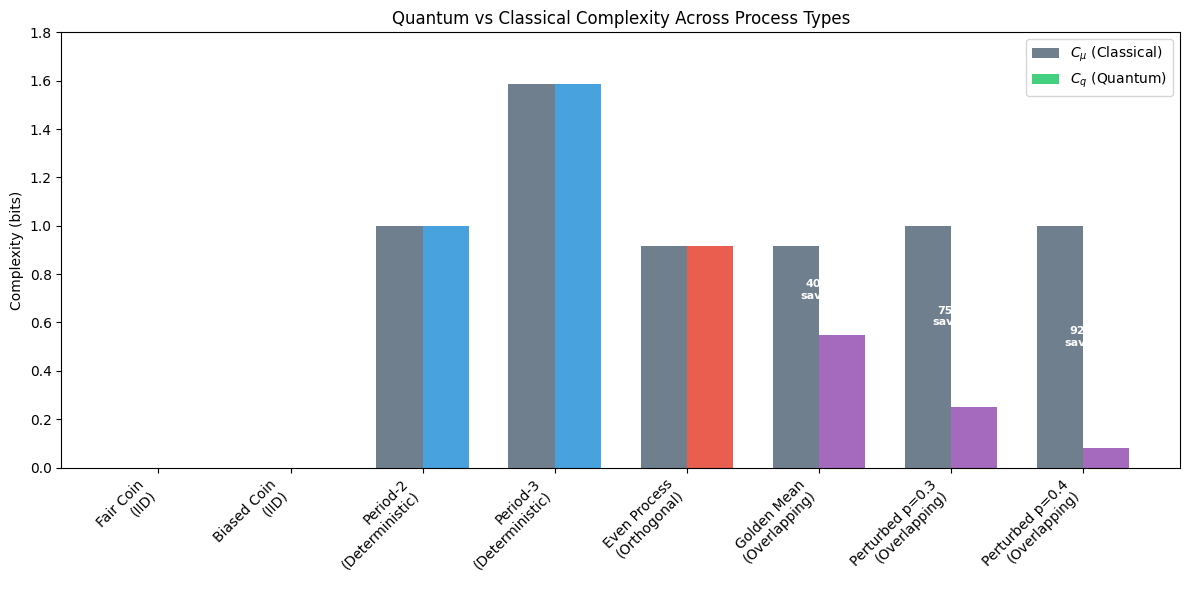


Legend:
  Green: IID (no memory needed)
  Blue: Deterministic (orthogonal by construction)
  Red: Non-trivial but orthogonal signal states
  Purple: Overlapping signal states → quantum advantage


In [ ]:
# Visual summary: Bar chart of quantum advantage by process type
import matplotlib.pyplot as plt

# Collect data for visualization
viz_data = [
    ("Fair Coin\n(IID)", 0.0, 0.0, "IID"),
    ("Biased Coin\n(IID)", 0.0, 0.0, "IID"),
    ("Period-2\n(Deterministic)", 1.0, 1.0, "Deterministic"),
    ("Period-3\n(Deterministic)", 1.585, 1.585, "Deterministic"),
    ("Even Process\n(Orthogonal)", 0.918, 0.918, "No Advantage"),
    ("Golden Mean\n(Overlapping)", 0.918, 0.550, "Advantage"),
    ("Perturbed p=0.3\n(Overlapping)", 1.0, 0.250, "Advantage"),
    ("Perturbed p=0.4\n(Overlapping)", 1.0, 0.081, "Advantage"),
]

names = [d[0] for d in viz_data]
c_mu = [d[1] for d in viz_data]
c_q = [d[2] for d in viz_data]
categories = [d[3] for d in viz_data]

# Color by category
colors = {
    "IID": "#2ecc71",
    "Deterministic": "#3498db",
    "No Advantage": "#e74c3c",
    "Advantage": "#9b59b6",
}

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width / 2, c_mu, width, label="$C_\\mu$ (Classical)", color="#34495e", alpha=0.7)
bars2 = ax.bar(
    x + width / 2,
    c_q,
    width,
    label="$C_q$ (Quantum)",
    color=[colors[c] for c in categories],
    alpha=0.9,
)

ax.set_ylabel("Complexity (bits)")
ax.set_title("Quantum vs Classical Complexity Across Process Types")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.8)

# Add quantum advantage annotations
for i, (cm, cq) in enumerate(zip(c_mu, c_q)):
    if cm > cq + 0.01:
        advantage = (cm - cq) / cm * 100
        ax.annotate(
            f"{advantage:.0f}%\nsaved",
            xy=(i, (cm + cq) / 2),
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            weight="bold",
        )

plt.tight_layout()
plt.show()

print("\nLegend:")
print("  Green: IID (no memory needed)")
print("  Blue: Deterministic (orthogonal by construction)")
print("  Red: Non-trivial but orthogonal signal states")
print("  Purple: Overlapping signal states → quantum advantage")

## Conclusions

### Validated Results

1. **Perturbed Coin**: Our implementation exactly matches the analytic formula from Gu et al. (2012)
   - $C_q$ values verified for $p = 0.05, 0.10, \ldots, 0.45$ with tolerance $< 0.01$ bits

2. **Hierarchy**: $E \leq C_q \leq C_\mu$ verified for all 10 test processes

3. **Decoherence Trajectory**: $C_q(\gamma)$ correctly interpolates from $C_q$ to $C_\mu$ for perturbed coin

### Key Insight: The Signal State Overlap Criterion

**Quantum advantage occurs if and only if the ε-machine has merging paths.**

More precisely, if two different causal states $s_j$ and $s_k$ can both:
- Emit the same symbol $x$
- Transition to the same target state $l$

Then $\langle s_j | s_k \rangle > 0$, and quantum encoding saves memory.

### Processes WITHOUT Advantage

| Process | Why No Advantage |
|---------|------------------|
| IID | Single state → pure state → $S(\rho) = 0$ |
| Deterministic | Each state has unique output → orthogonal signal states |
| Even Process | States have disjoint output alphabets → orthogonal |

### Processes WITH Advantage

| Process | Why Advantage | Max Savings |
|---------|---------------|-------------|
| Perturbed Coin ($p \to 0.5$) | Symmetric transitions → max overlap | Up to 100% |
| Golden Mean | Shared $S_0 \to S_0$ transition | ~40% |

### What This Means

The quantum memory advantage is not mysterious — it's a precise consequence of the causal structure.
When different pasts "inevitably merge" into the same future, the information distinguishing them is **destined to be lost**. 
Classical models store this doomed information anyway. 
Quantum models are more parsimonious.